In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(67)

In [3]:
def gd(f, grad, x0, alpha, n_steps):
    x = x0.astype(float).copy()
    xs = [x.copy()]
    fs = [float(f(x))]
    for _ in range(n_steps):
        x = x - alpha * grad(x)
        xs.append(x.copy())
        fs.append(float(f(x)))
    return np.stack(xs), np.array(fs)

# Funcion y trayectoria del GD
def plot_contours_and_path(f, xlim, ylim, path, title, n_grid=200):
    x = np.linspace(xlim[0], xlim[1], n_grid)
    y = np.linspace(ylim[0], ylim[1], n_grid)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)
    for i in range(n_grid):
        for j in range(n_grid):
            Z[i, j] = f(np.array([X[i, j], Y[i, j]]))

    plt.contour(X, Y, Z, levels=30)
    plt.plot(path[:, 0], path[:, 1], marker="o")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)

def safe_log10(x):  # Para que no explote
    x = np.asarray(x)
    return np.log10(np.maximum(x, 1e-20))

## Gradiente descendente

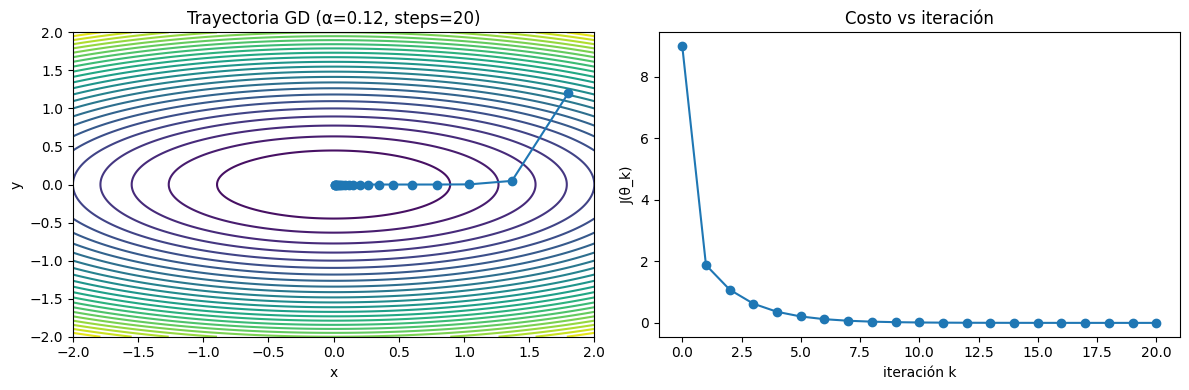

In [4]:
def f(z):
    x, y = z
    return x**2 + 4*y**2

def grad(z):
    x, y = z
    return np.array([2*x, 8*y])

z0 = np.array([1.8, 1.2])
alpha = 0.12
n_steps = 20

path, costs = gd(f, grad, z0, alpha, n_steps)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plt.sca(axes[0])
plot_contours_and_path(f, xlim=(-2, 2), ylim=(-2, 2), path=path,
                        title=f"Trayectoria GD (α={alpha}, steps={n_steps})")

plt.sca(axes[1])
axes[1].plot(np.arange(costs.size), costs, marker="o")
axes[1].set_xlabel("iteración k")
axes[1].set_ylabel("J(θ_k)")
axes[1].set_title("Costo vs iteración")

plt.tight_layout()
plt.show()

## Magnitud de α

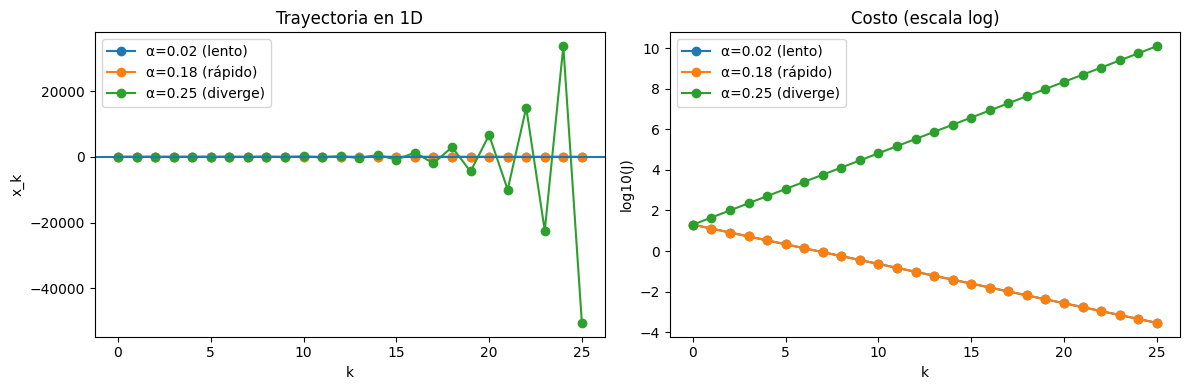

In [5]:
L = 10.0

def f(x):
    return 0.5 * L * x**2

def grad(x):
    return L * x

x0 = 2.0
n_steps = 25

alpha_small = 0.02
alpha_good  = 0.18
alpha_bad   = 0.25  # > 2/L = 0.2  -> diverge

alphas = [alpha_small, alpha_good, alpha_bad]
labels = [f"α={alpha_small} (lento)", f"α={alpha_good} (rápido)", f"α={alpha_bad} (diverge)"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for a, lab in zip(alphas, labels):
    xs = [x0]
    x = x0
    for _ in range(n_steps):
        x = x - a * grad(x)
        xs.append(x)
    axes[0].plot(xs, marker="o", label=lab)
axes[0].axhline(0)
axes[0].set_xlabel("k")
axes[0].set_ylabel("x_k")
axes[0].set_title("Trayectoria en 1D")
axes[0].legend()

for a, lab in zip(alphas, labels):
    xs = [x0]
    x = x0
    for _ in range(n_steps):
        x = x - a * grad(x)
        xs.append(x)
    costs = [f(x) for x in xs]
    axes[1].plot(safe_log10(costs), marker="o", label=lab)
axes[1].set_xlabel("k")
axes[1].set_ylabel("log10(J)")
axes[1].set_title("Costo (escala log)")
axes[1].legend()

plt.tight_layout()
plt.show()

## Convexa vs no convexa

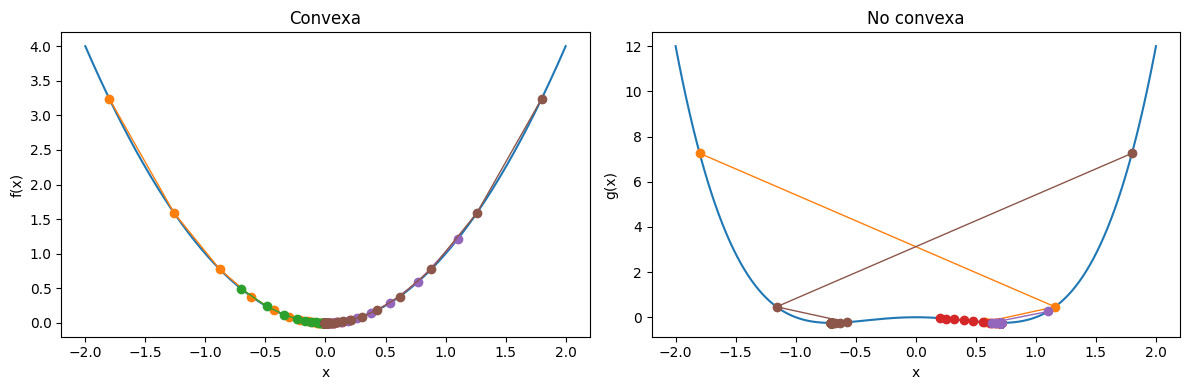

In [6]:
def gd_1d(f, grad, x0, alpha, n_steps):
    xs = [float(x0)]
    fs = [float(f(x0))]
    x = float(x0)
    for _ in range(n_steps):
        x = x - alpha * grad(x)
        xs.append(float(x))
        fs.append(float(f(x)))
    return np.array(xs), np.array(fs)

def f(x):
    return x**2

def df(x):
    return 2*x

def g(x):
    return x**4 - x**2

def dg(x):
    return 4*x**3 - 2*x

x_grid = np.linspace(-2, 2, 400)

# Inicializaciones
inits = [-1.8, -0.7, 0.2, 1.1, 1.8]
alpha = 0.15
n_steps = 40

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Convexa
axes[0].plot(x_grid, [f(x) for x in x_grid])
for x0 in inits:
    xs, _ = gd_1d(f, df, x0, alpha, n_steps)
    axes[0].plot(xs, [f(x) for x in xs], marker="o", linewidth=1)
axes[0].set_title("Convexa")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")

# No convexa
axes[1].plot(x_grid, [g(x) for x in x_grid])
for x0 in inits:
    xs, _ = gd_1d(g, dg, x0, alpha, n_steps)
    axes[1].plot(xs, [g(x) for x in xs], marker="o", linewidth=1)
axes[1].set_title("No convexa")
axes[1].set_xlabel("x")
axes[1].set_ylabel("g(x)")

plt.tight_layout()
plt.show()

OLS vs GD ==============
w_true (con intercepto): [ 0.5  2.  -1. ]
w_ols : [ 0.48712095  2.02592454 -0.9254943 ]
w_gd  : [ 0.48712097  2.02592456 -0.92549432]
||w_gd - w_ols|| = 3.459846947572486e-08
J(w0) = 6.144200402868668    J(w_gd) = 0.5344738624016692    J(w_ols) = 0.5344738624016677
L = 2.182744468032688  -> rango estable aprox 0 < α < 2/L = 0.916277662956399


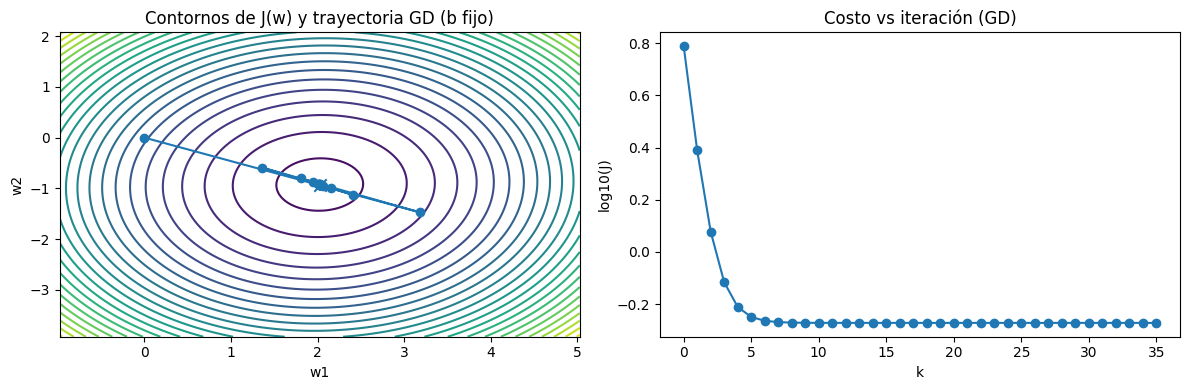

In [8]:
m = 180
n = 2
sigma = 0.7

# Datos
X = rng.normal(size=(m, n))
w_true = np.array([2.0, -1.0])
b_true = 0.5
y = X @ w_true + b_true + rng.normal(0, sigma, size=m)

Xd = np.c_[np.ones((m, 1)), X]  # intercepto
p = Xd.shape[1]

# OLS
w_ols = np.linalg.pinv(Xd) @ y

# Costo
def J(w):
    r = Xd @ w - y
    return (1.0 / m) * float(r @ r)

def gradJ(w):
    r = Xd @ w - y
    return (2.0 / m) * (Xd.T @ r)

# L teórico
XtX = Xd.T @ Xd
lam_max = np.linalg.eigvalsh(XtX).max()
L = (2.0 / m) * lam_max
alpha = 1.6 / L
n_steps = 35

w0 = np.zeros(p)
path, costs = gd(J, gradJ, w0, alpha, n_steps)

w_gd = path[-1]

print("OLS vs GD ==============")
print("w_true (con intercepto):", np.r_[b_true, w_true])
print("w_ols :", w_ols)
print("w_gd  :", w_gd)
print("||w_gd - w_ols|| =", np.linalg.norm(w_gd - w_ols))
print("J(w0) =", costs[0], "   J(w_gd) =", costs[-1], "   J(w_ols) =", J(w_ols))
print("L =", L, " -> rango estable aprox 0 < α < 2/L =", 2.0 / L)

b_fixed = float(w_ols[0])

def J_2d(w1, w2):
    w = np.array([b_fixed, w1, w2])
    return J(w)

# Grid
w1s = np.linspace(w_ols[1] - 3.0, w_ols[1] + 3.0, 160)
w2s = np.linspace(w_ols[2] - 3.0, w_ols[2] + 3.0, 160)
W1, W2 = np.meshgrid(w1s, w2s)
Z = np.zeros_like(W1)
for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        Z[i, j] = J_2d(W1[i, j], W2[i, j])

# Trayectoria en el plano (w1,w2) con b fijo
path_2d = path[:, 1:3]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].contour(W1, W2, Z, levels=30)
axes[0].plot(path_2d[:, 0], path_2d[:, 1], marker="o")
axes[0].scatter([w_ols[1]], [w_ols[2]], marker="x", s=80)
axes[0].set_xlabel("w1")
axes[0].set_ylabel("w2")
axes[0].set_title("Contornos de J(w) y trayectoria GD (b fijo)")

axes[1].plot(safe_log10(costs), marker="o")
axes[1].set_xlabel("k")
axes[1].set_ylabel("log10(J)")
axes[1].set_title("Costo vs iteración (GD)")

plt.tight_layout()
plt.show()